Exploratory Data Analysis : to understand feature distributions and relationships with churn.

import pandas as pd 
from sklearn.feature_selection import f_classif
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import pandas as pd
df = pd.read_csv("clean.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        7032 non-null   int64  
 1   customerID        7032 non-null   object 
 2   gender            7032 non-null   object 
 3   SeniorCitizen     7032 non-null   int64  
 4   Partner           7032 non-null   object 
 5   Dependents        7032 non-null   object 
 6   tenure            7032 non-null   int64  
 7   PhoneService      7032 non-null   object 
 8   MultipleLines     7032 non-null   object 
 9   InternetService   7032 non-null   object 
 10  OnlineSecurity    7032 non-null   object 
 11  OnlineBackup      7032 non-null   object 
 12  DeviceProtection  7032 non-null   object 
 13  TechSupport       7032 non-null   object 
 14  StreamingTV       7032 non-null   object 
 15  StreamingMovies   7032 non-null   object 
 16  Contract          7032 non-null   object 


In [4]:
df.dtypes


Unnamed: 0            int64
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

Features: 

Categorical = 16

Numerical = 4 


Checking feature importance of the categorical features  according to  number of categories each vairibale has 

In [7]:
Check_categories = ['gender','Partner','Dependents','PhoneService','MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','Contract','PaperlessBilling','PaymentMethod','Churn']   

for cat in Check_categories:
    print(f"{cat} -> {df[cat].unique()}")

gender -> ['Female' 'Male']
Partner -> ['Yes' 'No']
Dependents -> ['No' 'Yes']
PhoneService -> ['No' 'Yes']
MultipleLines -> ['No phone service' 'No' 'Yes']
InternetService -> ['DSL' 'Fiber optic' 'No']
OnlineSecurity -> ['No' 'Yes' 'No internet service']
OnlineBackup -> ['Yes' 'No' 'No internet service']
DeviceProtection -> ['No' 'Yes' 'No internet service']
TechSupport -> ['No' 'Yes' 'No internet service']
StreamingTV -> ['No' 'Yes' 'No internet service']
StreamingMovies -> ['No' 'Yes' 'No internet service']
Contract -> ['Month-to-month' 'One year' 'Two year']
PaperlessBilling -> ['Yes' 'No']
PaymentMethod -> ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn -> ['No' 'Yes']


Checking feature importance of the numerical features  according to correlation 

In [9]:
target = 'Churn'

num_cols = df.select_dtypes(include = ['int64','float64']).columns
X = df[num_cols]
y = df[target]

f_scores,p_values = f_classif(X,y)

result = pd.DataFrame({
    'Feature': num_cols,
    'F_score' : f_scores,
    'P_value' : p_values
})

result = result.sort_values(by = 'F_score', ascending= False)

print(result)


          Feature      F_score        P_value
2          tenure  1007.509431  9.437650e-207
4    TotalCharges   291.344862   4.876866e-64
3  MonthlyCharges   271.576990   6.760843e-60
1   SeniorCitizen   163.012426   6.377295e-37
0      Unnamed: 0     0.721862   3.955629e-01


“We selected a subset of 13 features combining statistically significant numerical variables (via ANOVA F-test) and domain-relevant categorical variables. Redundant service-related features were reduced to avoid multicollinearity and over-encoding, ensuring clean EDA and stable model performance.”

## Univariate Analysis :

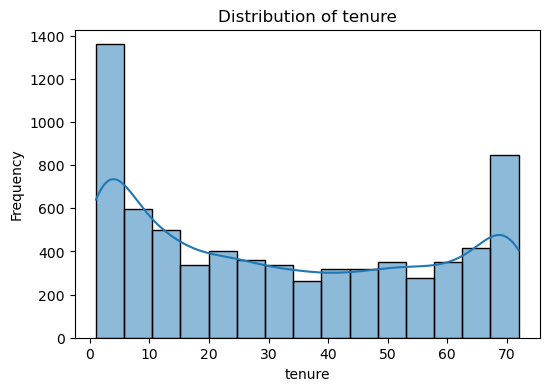

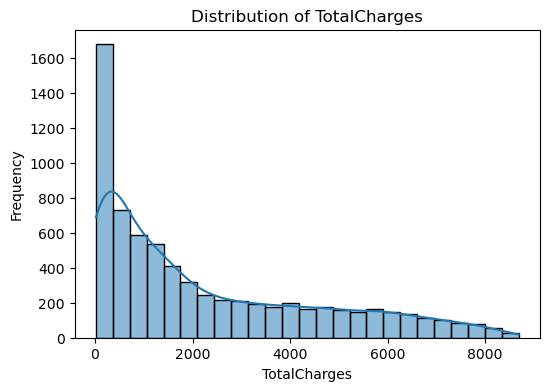

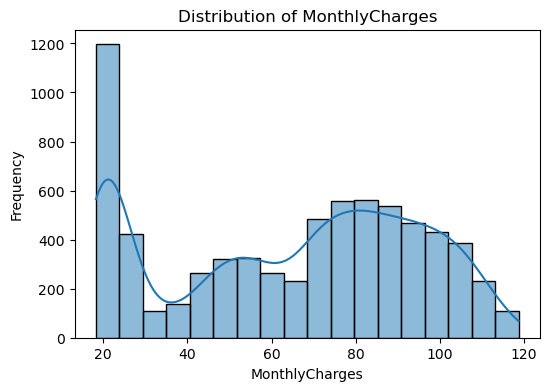

In [12]:
num_features = ['tenure','TotalCharges','MonthlyCharges']

for n_plot in num_features :
    plt.figure(figsize = (6,4))
    sns.histplot(df[n_plot],kde = True)
    plt.title(f"Distribution of {n_plot}")
    plt.xlabel(n_plot)
    plt.ylabel('Frequency')
    plt.show()


### Distribution of Numerical Features

The distribution of all three numerical features is **not normal**.

---

### Tenure

**Observations**
- Shows a higher frequency of customers with **very low tenure (0–10 months)**.
- Indicates that many customers either **leave early or stay for a long period**.
- A large number of **new customers** are present in the dataset.

**Insight**
- Early churn may be a key issue, suggesting the importance of **customer onboarding and early engagement strategies**.

---

### TotalCharges

**Observations**
- The distribution is **right-skewed**.
- Higher frequency of customers with **low TotalCharges**.

**Insight**
- This occurs because **new customers have lower accumulated charges**.
- **Feature scaling may be required** before training machine learning models.

---

### MonthlyCharges

**Observations**
- The distribution is **multimodal** (multiple peaks).

**Insight**
- This suggests customers belong to **different pricing tiers or service plans**, ranging from **basic to premium packages**.

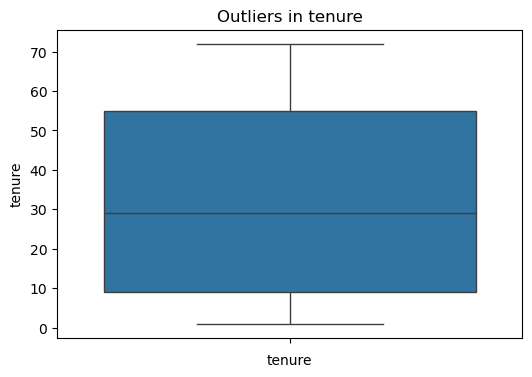

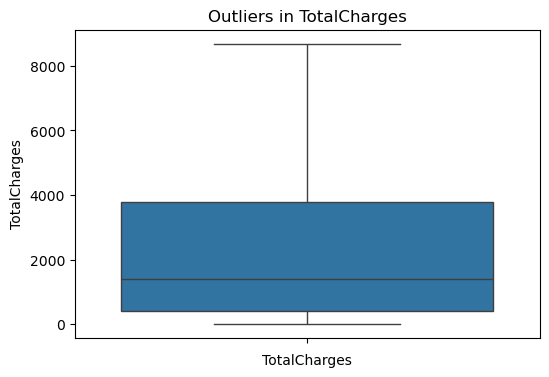

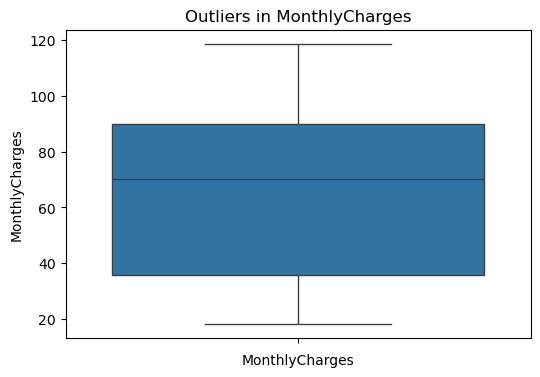

In [13]:

for n_plot in num_features :
    plt.figure(figsize = (6,4))
    sns.boxplot(df[n_plot])
    plt.title(f"Outliers in {n_plot}")
    plt.xlabel(n_plot)
    
    plt.show()

In above plots : 

NO Significant Outliers are being detected.


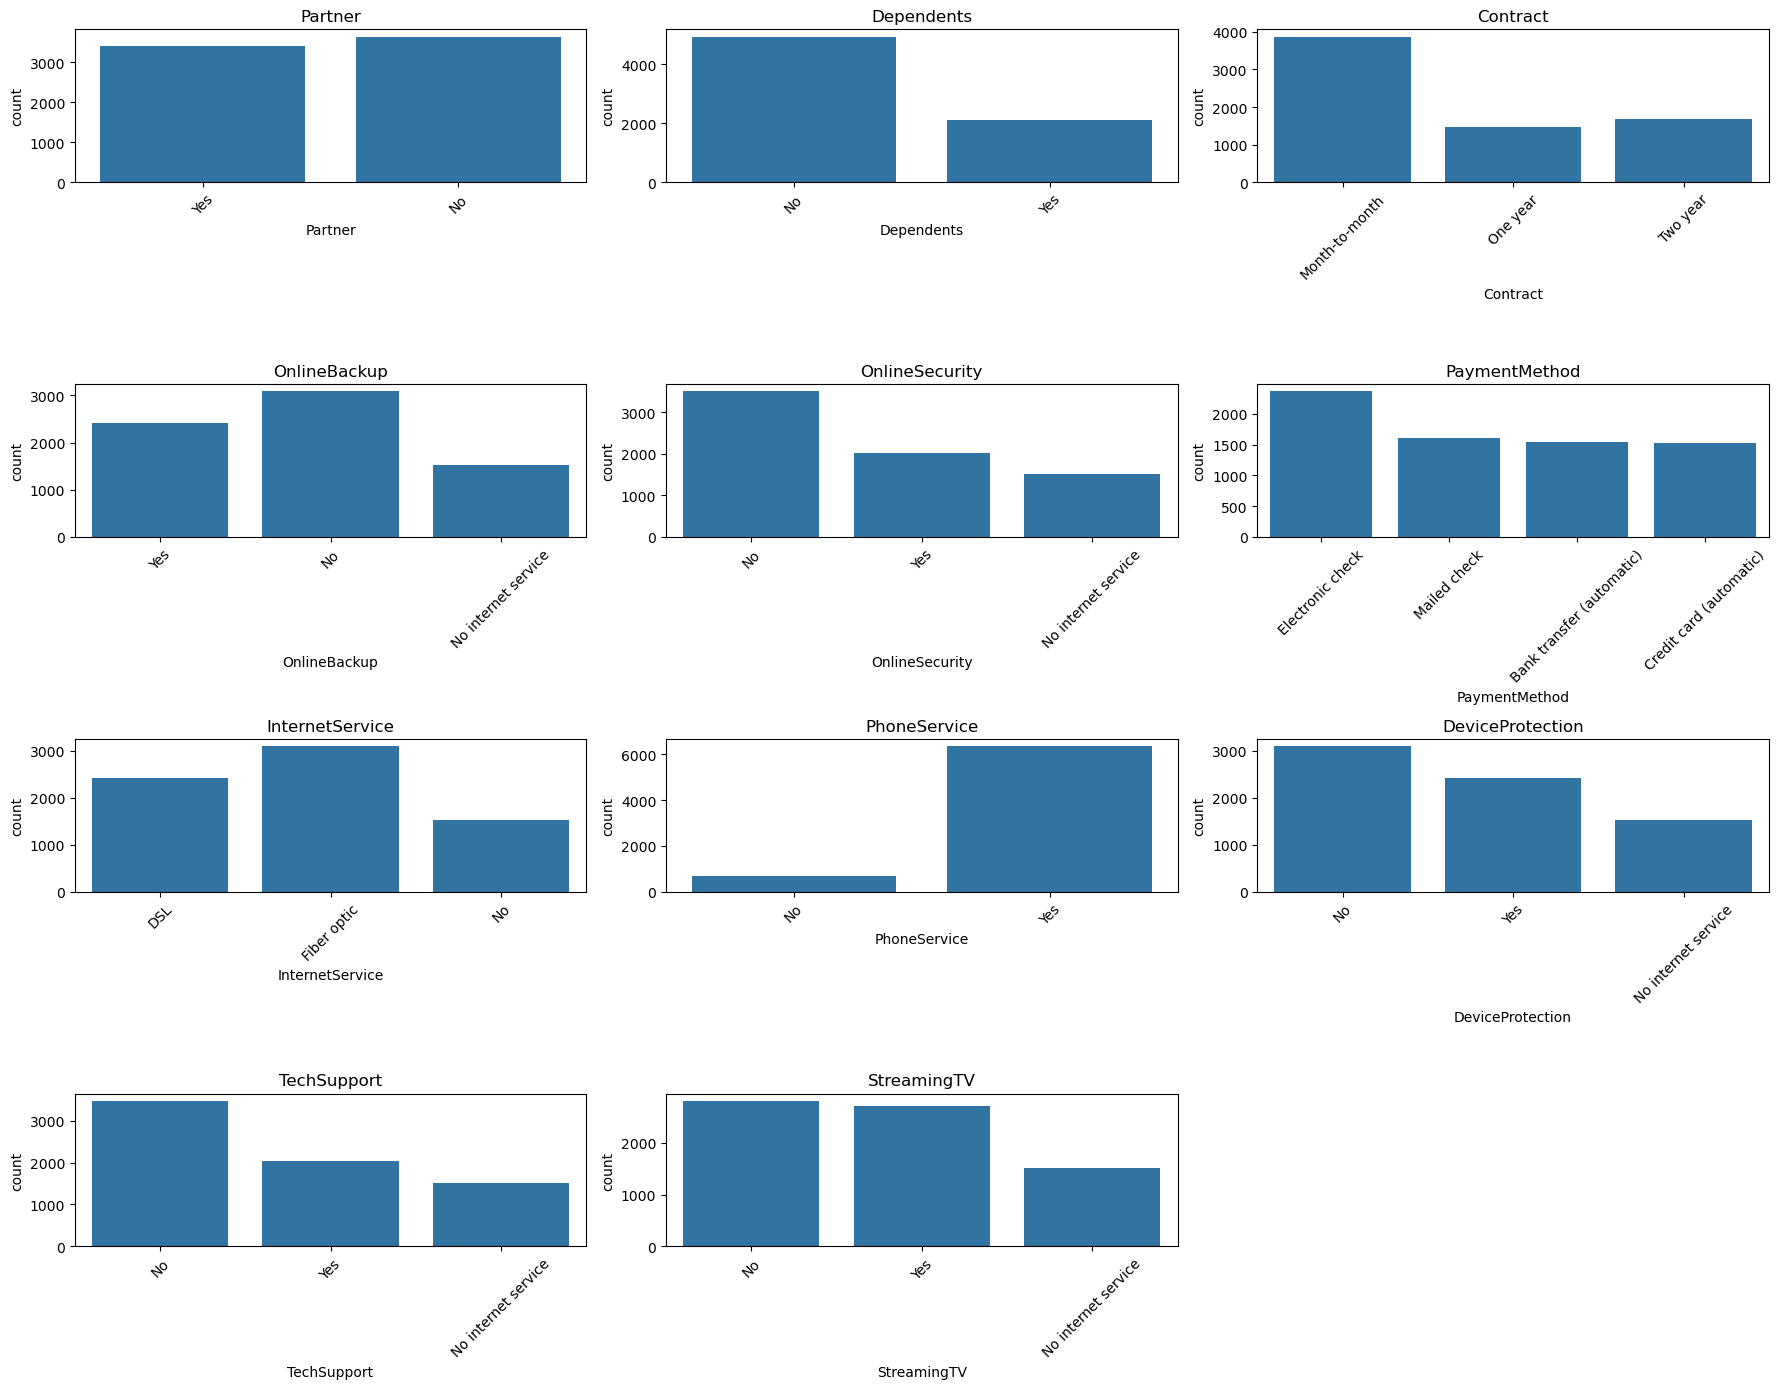

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns


df.columns = df.columns.str.strip()

cat_features = [
    'Partner','Dependents','Contract','OnlineBackup','OnlineSecurity',
    'PaymentMethod','InternetService','PhoneService','DeviceProtection',
    'TechSupport','StreamingTV'
]

fig, axes = plt.subplots(4, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    sns.countplot(x=col, data=df, ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

# remove empty subplots
for j in range(len(cat_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


## Distribution of Categorical Features

The following visualizations show the **distribution of different categorical variables** in the dataset. These help understand the customer base and service usage patterns.

---

### Partner

**Observations**
- The number of customers with a **partner and without a partner is almost balanced**.
- Slightly more customers appear to **not have a partner**.

**Insight**
- Relationship status is **fairly evenly distributed**, meaning it may or may not have a strong effect on churn and should be analyzed further with churn comparison.

---

### Dependents

**Observations**
- Most customers **do not have dependents**.
- Customers with dependents form a **smaller portion of the dataset**.

**Insight**
- Customers without dependents might represent **younger or single users**, which could influence service usage patterns.

---

### Contract

**Observations**
- **Month-to-month contracts dominate the dataset**.
- One-year and two-year contracts are significantly fewer.

**Insight**
- Customers with **short-term contracts may have a higher chance of churn** because they are not locked into long-term commitments.

---

### OnlineBackup

**Observations**
- Many customers **do not use online backup services**.
- A moderate number of customers **use online backup**.
- Some customers show **"No Internet Service"**, meaning the service is unavailable to them.

**Insight**
- Additional services like backup are **not widely adopted by all users**, indicating potential upselling opportunities.

---

### OnlineSecurity

**Observations**
- A large portion of customers **do not have online security services**.
- Fewer customers have enabled this service.

**Insight**
- Security services have **lower adoption**, which might influence customer retention and perceived service value.

---

### PaymentMethod

**Observations**
- **Electronic check is the most common payment method**.
- Other payment methods such as **mailed check, bank transfer, and credit card** are used by fewer customers.

**Insight**
- Payment method preference may correlate with **customer demographics or churn behavior**.

---

### InternetService

**Observations**
- **Fiber optic and DSL** are the primary internet services used.
- A smaller number of customers **do not have internet service**.

**Insight**
- Fiber optic users might have **different pricing and service experiences** compared to DSL users.

---

### PhoneService

**Observations**
- The majority of customers **have phone service**.
- Only a small portion **do not use phone service**.

**Insight**
- Phone service is a **common base service** among customers.

---

### DeviceProtection

**Observations**
- Many customers **do not use device protection**.
- Some customers have the service enabled.
- A portion of users have **no internet service**, making this feature irrelevant.

**Insight**
- Additional protective services are **not widely adopted**, similar to backup and security services.

---

### TechSupport

**Observations**
- A large number of customers **do not use tech support services**.
- Fewer customers have active tech support.

**Insight**
- Low tech support usage may indicate **either good service stability or lack of awareness among customers**.

---

### StreamingTV

**Observations**
- Customers are **fairly evenly distributed between using and not using streaming TV**.
- Some customers do not have internet service.

**Insight**
- Streaming services represent an **optional entertainment add-on rather than a core service**.

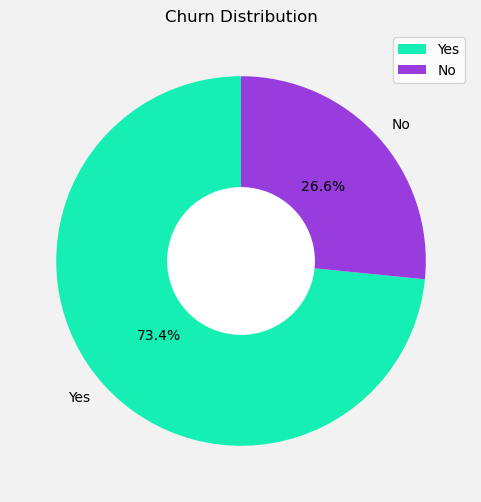

In [6]:
plt.figure(figsize = (6,6))
plt.gcf().set_facecolor('#f2f2f2')
plt.gca().set_facecolor('#faf7ff')


mylabels = ['Yes','No']
data = df['Churn'].value_counts()
colors = ['#15EFB4','#983CDE']

plt.pie(x= data, labels = mylabels,
       autopct = '%1.1f%%',startangle = 90,colors = colors)
centre_circle = plt.Circle((0,0),0.40,fc = 'white')
plt.gca().add_artist(centre_circle)
plt.legend(mylabels, loc = 'upper right' ,  bbox_to_anchor  =(1,1) )
plt.grid(True)
plt.title('Churn Distribution')
plt.show()


### Churn Distribution

#### Observations
- The majority of customers belong to the **non-churn category (No)**.
- Around **73.4% of customers did not churn**, indicating that most customers stayed with the company.
- Approximately **26.6% of customers churned**, representing the portion of customers who left the service.

#### Insights
- The dataset is **imbalanced**, as the number of non-churn customers is significantly higher than churn customers.
- This imbalance should be considered during **model training**, since models may become biased toward predicting the majority class.
- Techniques such as **class balancing, resampling, or evaluation metrics like F1-score and ROC-AUC** may be useful when building predictive models.

#### Conclusion
- Customer churn exists but represents a **smaller portion of the dataset (26.6%)**.


## BIVARIATE ANALYSIS : 

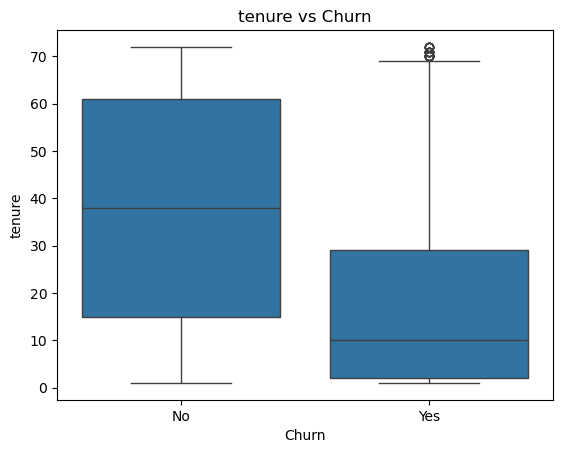

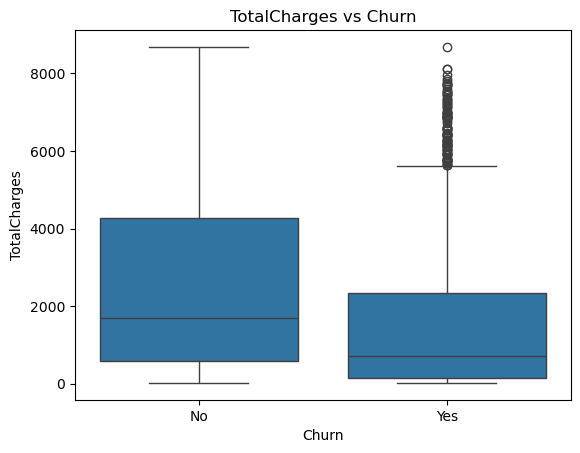

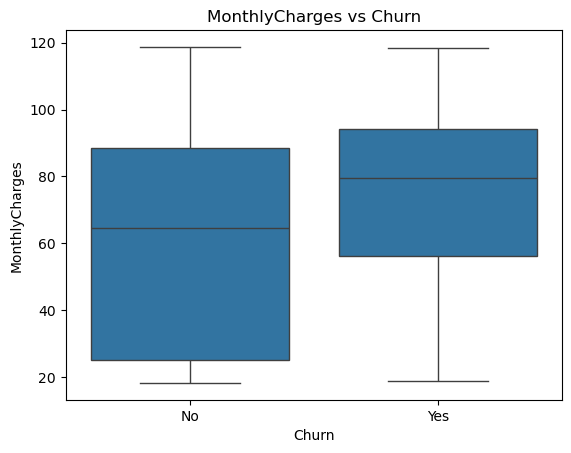

In [41]:
num_cols  = ['tenure','TotalCharges','MonthlyCharges']
for cols in num_cols:
    sns.boxplot(x = 'Churn',y = cols , data = df)
    plt.title(f"{cols} vs Churn")
    plt.show()

# Bivariate Analysis: Numerical Features vs Churn

## Tenure vs Churn

### Observations
- Customers who **did not churn** tend to have higher tenure values.
- Customers who **churned** generally have lower tenure, mostly within the **early months of service**.

### Insights
- This suggests that **new customers are more likely to churn**.
- Customers who stay longer with the company tend to **remain loyal and continue using the service**.

---

## TotalCharges vs Churn

### Observations
- Customers who **did not churn** generally have higher total charges.
- Customers who **churned** tend to have lower total charges.

### Insights
- Since **TotalCharges increases with tenure**, customers who leave early accumulate lower total charges.
- **Long-term customers contribute more total revenue** and are less likely to churn.

---

## MonthlyCharges vs Churn

### Observations
- Customers who **churned** tend to have higher monthly charges compared to customers who stayed.
- The **median monthly charge** for churned customers appears higher.

### Insights
- Higher monthly charges may **increase the probability of churn**.
- Customers paying more each month might **switch to competitors offering cheaper services**.

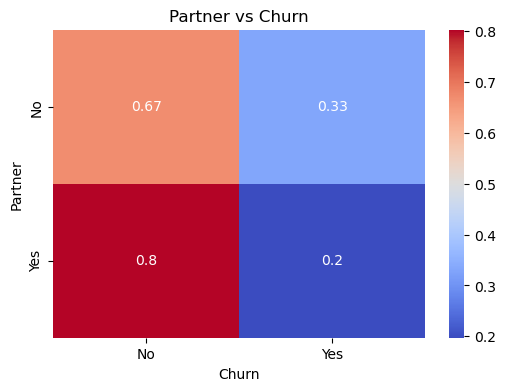

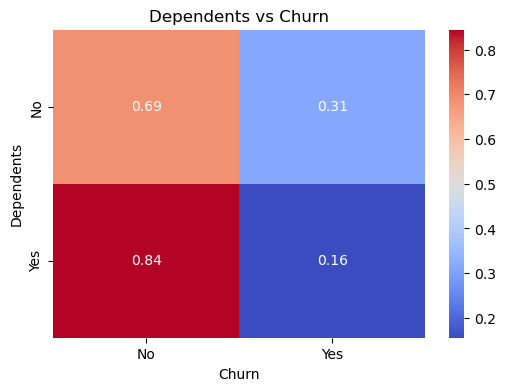

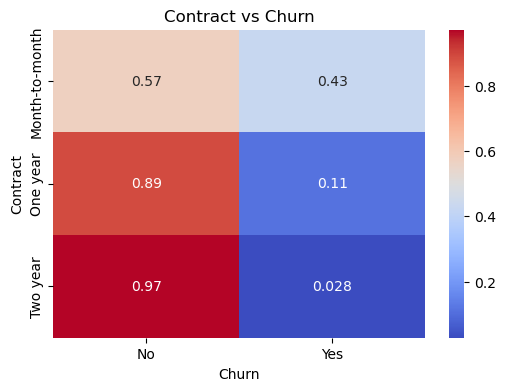

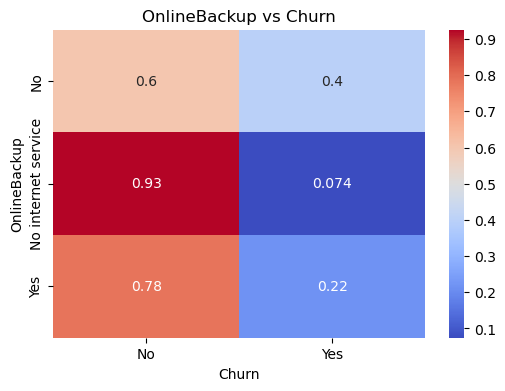

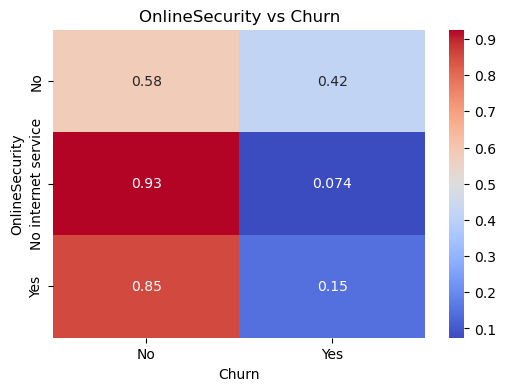

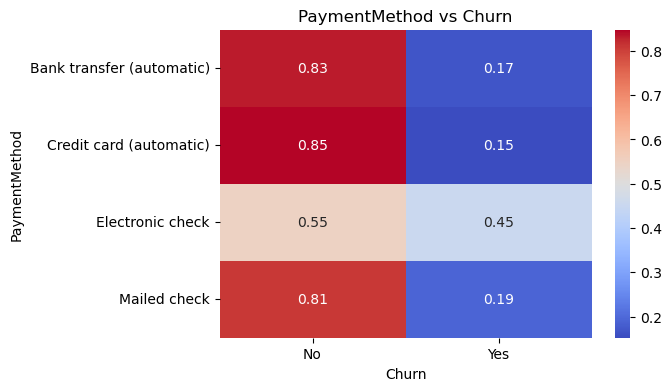

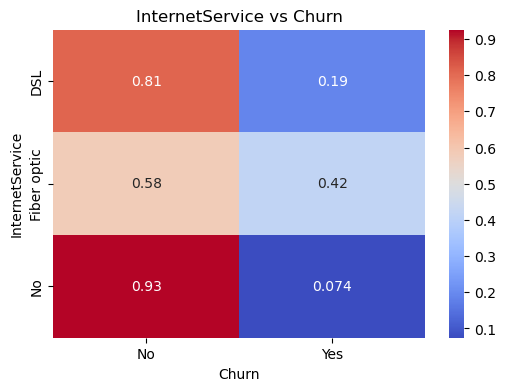

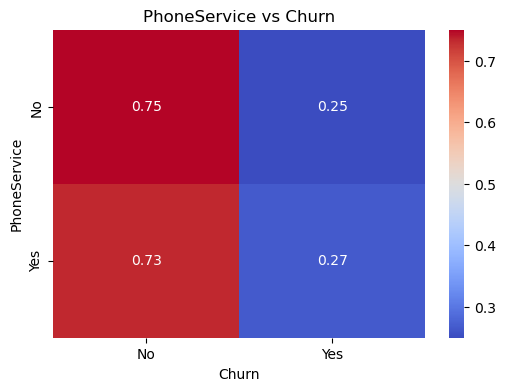

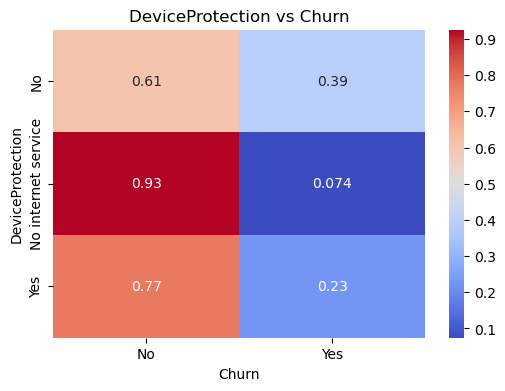

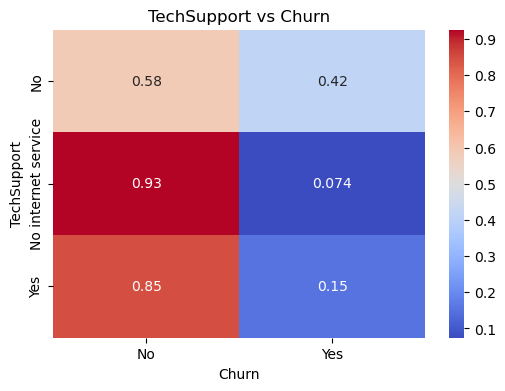

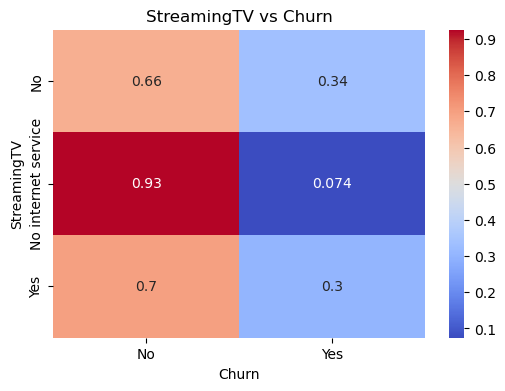

In [54]:
cat_cols= [
    'Partner','Dependents','Contract','OnlineBackup','OnlineSecurity',
    'PaymentMethod','InternetService','PhoneService','DeviceProtection',
    'TechSupport','StreamingTV'
]
for col in cat_cols:
    ct = pd.crosstab(df[col], df['Churn'], normalize='index')

    plt.figure(figsize=(6,4))
    sns.heatmap(ct, annot=True, cmap='coolwarm')
    plt.title(f"{col} vs Churn")
    plt.show()

# Bivariate Analysis: Categorical Features vs Churn

## Partner vs Churn

### Observations
- Customers **without a partner** have a higher churn rate (~33%).
- Customers **with a partner** show a lower churn rate (~20%).

### Insight
Customers with partners may have **more stable service usage**, leading to lower churn.

---

## Dependents vs Churn

### Observations
- Customers **without dependents** have higher churn (~31%).
- Customers **with dependents** show significantly lower churn (~16%).

### Insight
Customers with dependents may **rely more on telecom services**, making them less likely to switch providers.

---

## Contract vs Churn

### Observations
- **Month-to-month contracts** have the highest churn rate (~43%).
- **One-year contracts** have much lower churn (~11%).
- **Two-year contracts** have the lowest churn (~3%).

### Insight
Longer contract commitments **significantly reduce churn probability**.

---

## OnlineBackup vs Churn

### Observations
- Customers **without online backup** have higher churn (~40%).
- Customers **with online backup** have lower churn (~22%).

### Insight
Additional services may **increase customer engagement and retention**.

---

## OnlineSecurity vs Churn

### Observations
- Customers **without online security** have higher churn (~42%).
- Customers **with online security** show much lower churn (~15%).

### Insight
Security services appear to **improve customer retention**.

---

## PaymentMethod vs Churn

### Observations
- **Electronic check users** show the highest churn (~45%).
- Customers using **automatic payments (bank transfer / credit card)** show lower churn (~15–17%).

### Insight
Automatic payments may indicate **more stable customers**.

---

## InternetService vs Churn

### Observations
- **Fiber optic users** show higher churn (~42%).
- **DSL users** have lower churn (~19%).
- Customers **without internet service** have very low churn.

### Insight
Fiber optic customers may have **higher expectations or higher costs**, increasing churn.

---

## PhoneService vs Churn

### Observations
- Churn rate is **similar for customers with and without phone service**.

### Insight
Phone service **does not strongly influence churn behavior**.

---

## DeviceProtection vs Churn

### Observations
- Customers **without device protection** have higher churn (~39%).
- Customers **with device protection** have lower churn (~23%).

### Insight
Additional protection services may **increase customer loyalty**.

---

## TechSupport vs Churn

### Observations
- Customers **without tech support** have high churn (~42%).
- Customers **with tech support** show much lower churn (~15%).

### Insight
Providing technical support **improves customer retention**.

---

## StreamingTV vs Churn

### Observations
- Customers **without streaming services** have slightly higher churn (~34%).

### Insight
Entertainment services may **increase engagement and slightly reduce churn**.